In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('dataset.csv') # Lee el dataset y lo almacena en el array df (data frame)
df = df.drop('id',axis=1) # Quitamos del data frame id porque no nos sirve para la predicción
X = df.drop('target_variable', axis=1) # Almacenamos las variables en x y quitamos el resultado (target_variable)
y = df['target_variable'] # Almacenamos el resultado en y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    random_state=42,
    n_estimators=50,
    max_depth=14,
    n_jobs=-1
)

model.fit(X_train, y_train)# per entrenar el model
y_pred = model.predict(X_test)# emmagatzema el predict amb X_test(features)
print("F1 Score:", f1_score(y_test, y_pred)) # Media harmonica entre la precision y el recall
# Precsión: De los positivos que detecta, cuantos de ellos son verdaderos
# Recall: De los positivos que hay, cuantos he detectado
# Si hay 10 positivos totales, y detecta 3 valores que considera positivos, si al final esos valores acaban siendo 1 falso positivo y 2 verdaderos positivos,
# la precisión seria 2/3 y el recall seria 2/10
print("Accuracy:", accuracy_score(y_test, y_pred)) # Cuanto porcentaje de acertar la predicción tiene
print("Confusion:", confusion_matrix(y_test,y_pred)) # Muestra falsos positivos y negativos y verdaderos positivos y negativos


F1 Score: 0.8221722846441948
Accuracy: 0.8346796657381615
Confusion: [[3249  608]
 [ 579 2744]]


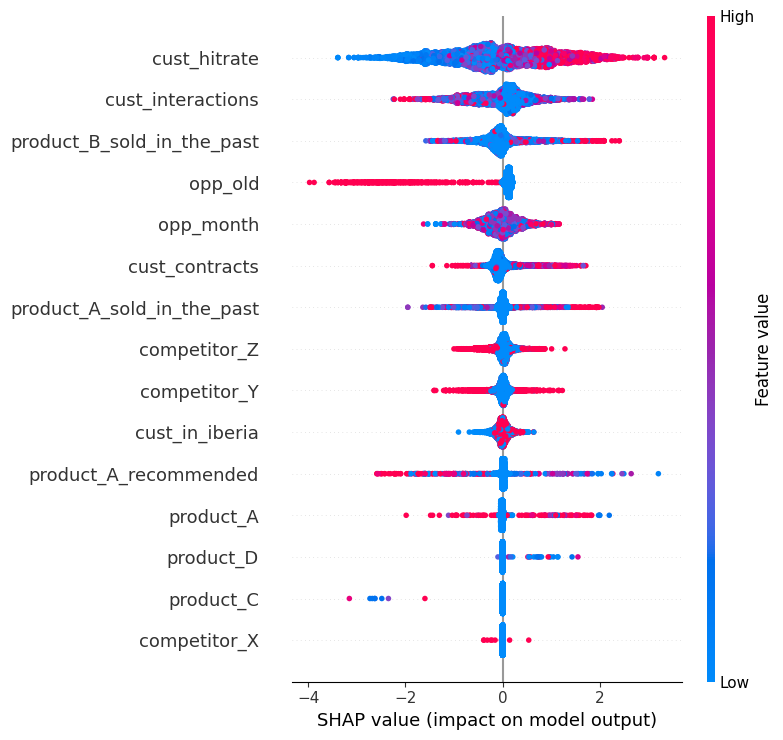

In [2]:
import shap
import matplotlib.pyplot as plt
from shap import initjs

# Crear el explainer para el modelo basado en árboles
explainer = shap.TreeExplainer(model)

# Calcular valores SHAP sobre X_test
shap_values = explainer.shap_values(X_test)  # Para binario devuelve array 2D

# Gráfico resumen de todos los features
shap.summary_plot(shap_values, X_test)
plt.show()

# Gráfico de explicación de un ejemplo concreto
initjs()
shap.force_plot(
    explainer.expected_value,  # valor base para binario
    shap_values[0, :],         # contribuciones de cada feature del primer ejemplo
    X_test.iloc[0, :]          # valores de las features del primer ejemplo
)
